In [2]:
import pandas as pd
import numpy as np

import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D

import seaborn as sns
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hello\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv(r"C:\Users\hello\OneDrive\Desktop\pap ki pari\train.csv")

print(df.head())

print(df.columns)

   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  
Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_tweet'] = df['tweet'].apply(clean_text)

In [5]:
X = df['clean_tweet']

y = df['class']

In [6]:
max_words = 20000

max_len = 100

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

X_pad = pad_sequences(X_seq,
                      maxlen=max_len)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

lstm_model.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(64, activation='relu'))

lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 128)          2560000   
                                                                 
 lstm_1 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 3)                 195       
                                                                 
Total params: 2700035 (10.30 MB)
Trainable params: 2700035 (10.30 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
history_lstm = lstm_model.fit(

    X_train,

    y_train,

    validation_split=0.1,

    epochs=10,

    batch_size=64

)

Epoch 1/10
279/279 [==============================] - 245s 841ms/step - loss: 0.4532 - accuracy: 0.8431 - val_loss: 0.3023 - val_accuracy: 0.8916
Epoch 2/10
279/279 [==============================] - 830s 3s/step - loss: 0.2308 - accuracy: 0.9203 - val_loss: 0.2744 - val_accuracy: 0.9002
Epoch 3/10
279/279 [==============================] - 1510s 5s/step - loss: 0.1438 - accuracy: 0.9503 - val_loss: 0.3350 - val_accuracy: 0.8961
Epoch 4/10
279/279 [==============================] - 429s 2s/step - loss: 0.0986 - accuracy: 0.9659 - val_loss: 0.3918 - val_accuracy: 0.8754
Epoch 5/10
279/279 [==============================] - 188s 674ms/step - loss: 0.0740 - accuracy: 0.9740 - val_loss: 0.4414 - val_accuracy: 0.8593
Epoch 6/10
279/279 [==============================] - 182s 651ms/step - loss: 0.0594 - accuracy: 0.9776 - val_loss: 0.6067 - val_accuracy: 0.8628
Epoch 7/10
279/279 [==============================] - 214s 766ms/step - loss: 0.0513 - accuracy: 0.9818 - val_loss: 0.5807 - val_acc

In [11]:
pred = lstm_model.predict(X_test)

pred = np.argmax(pred, axis=1)

print("Accuracy")

print(accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

155/155 [==============================] - 7s 39ms/step
Accuracy
0.861206374823482
              precision    recall  f1-score   support

           0       0.32      0.27      0.29       286
           1       0.91      0.92      0.92      3838
           2       0.78      0.79      0.79       833

    accuracy                           0.86      4957
   macro avg       0.67      0.66      0.66      4957
weighted avg       0.86      0.86      0.86      4957



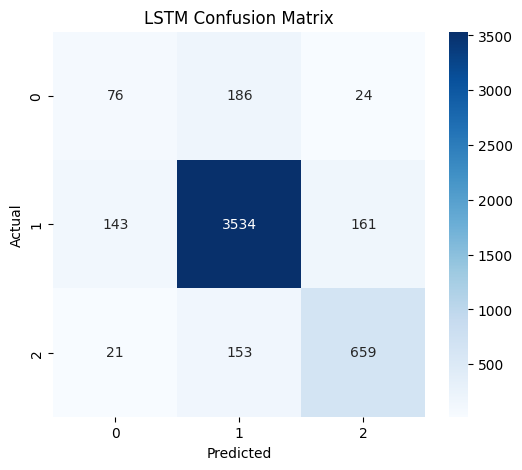

In [12]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("LSTM Confusion Matrix")

plt.show()

In [13]:
cnn_bilstm = Sequential()

cnn_bilstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

cnn_bilstm.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    )
)

cnn_bilstm.add(
    MaxPooling1D(pool_size=2)
)

cnn_bilstm.add(

    Bidirectional(

        LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )

    )

)

cnn_bilstm.add(Dropout(0.5))

cnn_bilstm.add(Dense(64, activation='relu'))

cnn_bilstm.add(Dense(3, activation='softmax'))

cnn_bilstm.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

cnn_bilstm.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 100, 128)          2560000   
                                                                 
 conv1d (Conv1D)             (None, 96, 128)           82048     
                                                                 
 max_pooling1d (MaxPooling1  (None, 48, 128)           0         
 D)                                                              
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)               

In [ ]:
history_cnn = cnn_bilstm.fit(

    X_train,

    y_train,

    validation_split=0.1,

    epochs=10,

    batch_size=64

)

In [ ]:
pred2 = cnn_bilstm.predict(X_test)

pred2 = np.argmax(pred2, axis=1)

print("Accuracy")

print(accuracy_score(y_test, pred2))

print(classification_report(y_test, pred2))

In [ ]:
cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CNN-BiLSTM Confusion Matrix")

plt.show()

In [ ]:
lstm_acc = accuracy_score(y_test, pred)

cnn_acc = accuracy_score(y_test, pred2)

print("LSTM Accuracy :", lstm_acc)

print("CNN-BiLSTM Accuracy :", cnn_acc)